In [1]:
import numpy as np
import pandas as pd
import joblib
from scipy.signal import welch
import matplotlib.pyplot as plt

In [55]:
def get_frequency(flux, fs):
    """
    Find the frequency of a planet's orbit by using signal.welch to calculate the frequency at 
    which the planet passes in front of the star, causing the flux (as measured from the kepler 
    telescope) to decrease

    Parameters
    ---------
    flux: np.array or pd.Series
        measured brightness of a star at different time points
    fs: float
        sampling frequency at which flux measurements were taken in Hz

    Returns
    ---------
    frequency: float
        the frequency of a planet's orbit in Hz
    power: float
        the percentage of all power contained in frequency
    """
    # Get frequencies and corresponding powers
    freqs, psd = welch(flux, fs=fs)

    # Find the frequency with the most power
    highest = np.argmax(psd)
    power = psd[highest] / np.sum(psd)
    frequency = freqs[highest]

    return frequency, power


In [56]:
def compute_radius(frequency, mass):
    """
    Computer the radius of a planet's orbit based on its frequency

    Parameters
    ---------
    frequency: float
        the frequency of a planet's orbit in Hz
    mass: float
        the mass of the orbited star in solar mass (1.988416 x 10^30 kg)

    Returns
    ---------
    radius: float
        the radius of a planet's orbit in kilometers
    """
    # Get gravitational constant, mass in kg, and compute radius
    G_const = 6.6743 * 10**(-11)
    M = mass * 1.988416 * 10**30
    radius = np.cbrt(G_const * M / (4 * np.pi**2 * frequency**2))

    # Convert from meters to kilometers
    radius = radius / 1000

    return radius

In [ ]:
# from lightkurve import search_lightcurve
# import numpy as np
# import joblib

In [ ]:
# subset_collectionq1 = {}
# ids = [11446443, 11414511, 9579641, 10583181, 8299955]
# # Given the slowness of the download we start with only a random subset
# for kid in ids:
#     # The try and except is for larger downloads that might have network troubles
#     try:
#         print(f"ID {kid}")
#         lc = search_lightcurve(f"KIC {kid}", quarter=1)
#         # Only download if data was found
#         if len(lc) > 0:
#             collection = lc.download_all()
#             subset_collectionq1[kid] = collection
#         else:
#             print(f"No data")
#     except Exception as e:
#         print(f"{kid} failed. Error {e}")

# simple_data_q1 = {}

# for kid, collection in subset_collectionq1.items():
#     lc = collection[0]
#     # This extracts the values as numpy arrays
#     simple_data_q1[kid] = {'time': lc.time.value, 'flux': lc.flux.value,'flux_err': lc.flux_err.value}
# joblib.dump(simple_data_q1, '5_stars.joblib', compress=3)
# print("File saved")

ID 11446443
ID 11414511
ID 9579641
ID 10583181
ID 8299955
File saved


RUn this on 3 chosen stars, use the pd.dataframe to get other features such as solar mass, etc

In [2]:
light_curve_dict = joblib.load("subset_q1.joblib")

Text(0, 0.5, 'Number of Occurences')

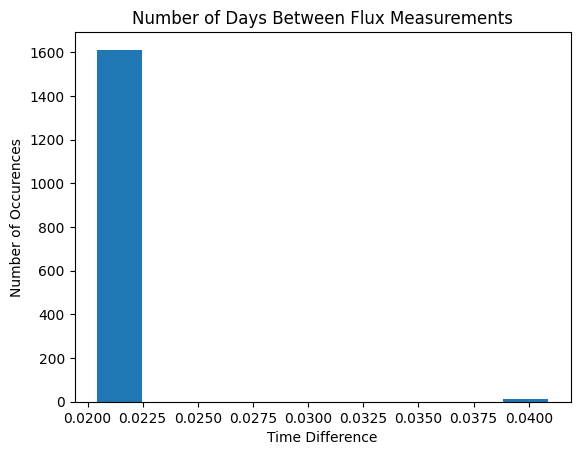

In [16]:
# Find how often measurements are taken
plt.hist(np.diff(t))
plt.title("Number of Days Between Flux Measurements")
plt.xlabel("Time Difference")
plt.ylabel("Number of Occurences")

In [19]:
# Because the majority of measurements are taken ~ every 0.02 days, we use this to find our sampling frequency and convert it to Hz
freq_days = np.mean(np.diff(t)[np.diff(t) < 0.025])
freq_hz = freq_days / (24 * 36 * 36)

Text(0, 0.5, 'Power')

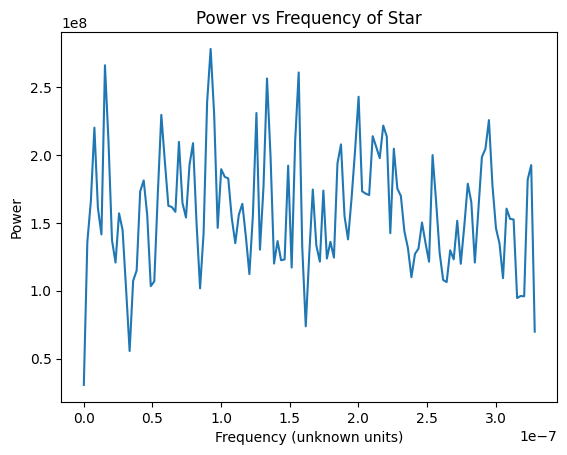

In [42]:
freqs, psd = welch(vals[~np.isnan(vals)], fs=freq_hz)

plt.plot(freqs, psd)
plt.title("Power vs Frequency of Star")
plt.xlabel("Frequency (unknown units)")
plt.ylabel("Power")

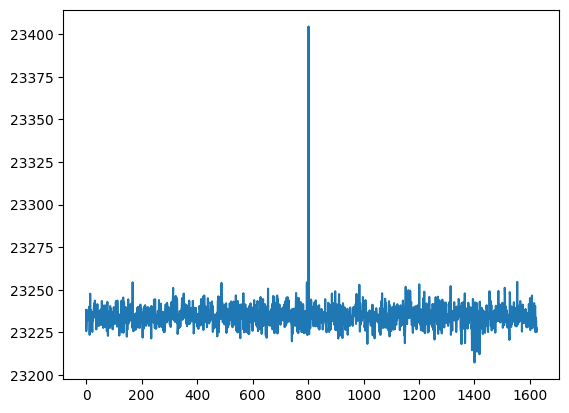

In [51]:
plt.plot(vals)

In [ ]:
t1, vals1, err1 = light_curve_dict[6949550][:3]


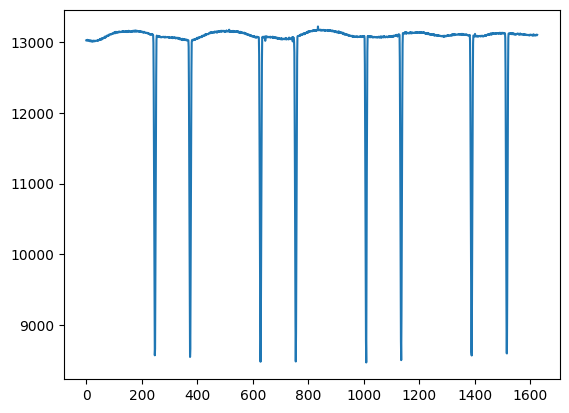

In [53]:
plt.plot(vals1)

Text(0, 0.5, 'Power')

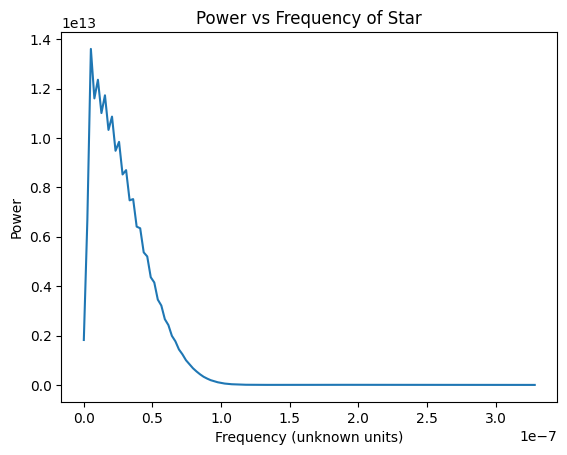

In [54]:
# Because the majority of measurements are taken ~ every 0.02 days, we use this to find our sampling frequency and convert it to Hz
freq_days1 = np.mean(np.diff(t1)[np.diff(t1) < 0.025])
freq_hz1 = freq_days1 / (24 * 36 * 36)

freqs1, psd1 = welch(vals1[~np.isnan(vals1)], fs=freq_hz1)

plt.plot(freqs1, psd1)
plt.title("Power vs Frequency of Star")
plt.xlabel("Frequency (unknown units)")
plt.ylabel("Power")

In [ ]:
freqs1, psd1 = get_frequency(vals1, freq_hz1)
radius1 = compute_radius(freqs1, mass1)

Figure out units for frequency, do we think the orbit frequency will have the highest power? higher than noise?, apply this to light_curve_dict

In [33]:
%cd ..
flux = pd.read_csv('exoTest.csv')

/Users/alicelundgren/Desktop/всё/ACME/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/Users/alicelundgren/Desktop/всё/ACME/vol3


Text(0, 0.5, 'Power')

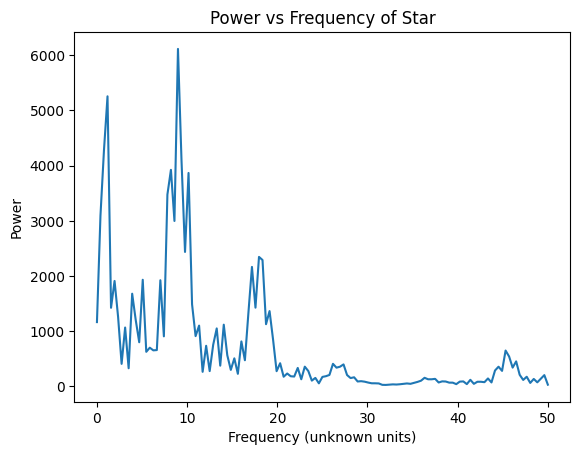

In [50]:
star2 = flux.iloc[568, 1:]

### find fs argument (frequency of sampling)
freqs, psd = welch(star2, fs=100)

plt.plot(freqs, psd)
plt.title("Power vs Frequency of Star")
plt.xlabel("Frequency (unknown units)")
plt.ylabel("Power")

Index(['LABEL', 'FLUX.1', 'FLUX.2', 'FLUX.3', 'FLUX.4', 'FLUX.5', 'FLUX.6',
       'FLUX.7', 'FLUX.8', 'FLUX.9',
       ...
       'FLUX.3188', 'FLUX.3189', 'FLUX.3190', 'FLUX.3191', 'FLUX.3192',
       'FLUX.3193', 'FLUX.3194', 'FLUX.3195', 'FLUX.3196', 'FLUX.3197'],
      dtype='object', length=3198)


Text(0, 0.5, 'Power')

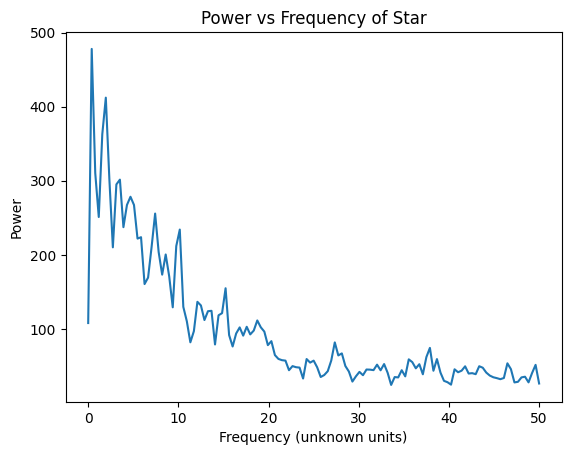

In [43]:
star1 = flux.iloc[8, 1:]
print(flux.columns)

### find fs argument (frequency of sampling)
freqs, psd = welch(star1, fs=100)

plt.plot(freqs, psd)
plt.title("Power vs Frequency of Star")
plt.xlabel("Frequency (unknown units)")
plt.ylabel("Power")

**One concern: do we want to take max frequency? do a weighted average of the top few?**

Next steps: compute sampling frequency from time between flux observations, determine if we want radius in km or solar radii, max frequency?, run on light_curve_dict